In [1]:
import scipy
from scipy.stats import median_abs_deviation as mad
import numpy as np
from matplotlib import pyplot as plt
import time
from  scipy.io import loadmat as loadmat
import lib

In [2]:
np.random.seed(12345)

In [3]:
rootfolder = '.'
# from google.colab import drive
# drive.mount('/content/drive')

Useful function for the plot

In [4]:
def display_band( X, par,epsi=0.001,col='k'):
    x1 = np.min(X[0, :])
    x2 = np.max(X[0, :])
    y1 = np.min(X[1, :])
    y2 = np.max(X[1, :])

    # extend the line for the k# of its lenght 
    k = 0.01
    dx = x2-x1
    dy = y2-y1
    l = np.sqrt(dx**2+dy**2)
    x1 = x1 - k*l
    x2 = x2 + k*l
    y1 = y1 - k*l
    y2 = y2 + k*l
    ##
    if np.abs(par[1])<2e-2 :
        #disp('vertical line')
        a = np.vstack([-(par[1]*y1 + par[2])/par[0], y1])
        b = np.vstack([-(par[1]*y2 + par[2])/par[0], y2])
    else:
        a = np.vstack([x1, -(par[0]*x1 + par[2])/par[1]])
        b = np.vstack([x2, -(par[0]*x2 + par[2])/par[1]])

    if np.abs(par[0])<1e-5:
        v = np.array([0,1]) 
    else:    
        v = np.array([1, par[1]/par[0]])# direction perpendicular to the line;

    v = v / np.sqrt(np.sum(v**2))
    # corners of the bands
    v = v[:, np.newaxis]
    a1 = a - epsi * v
    a2 = a + epsi * v
    b1 = b - epsi * v
    b2 = b + epsi * v

    px = np.array([a1[0], b1[0], b2[0], a2[0]]).squeeze()
    py = np.array([a1[1], b1[1], b2[1], a2[1]]).squeeze()
    plt.tricontourf(px,py,np.ones_like(px), colors=col,alpha=0.5)
    plt.gca().set_aspect('equal')

def display_clust(X, G, cmap):
    G = np.asarray(G, dtype=int)
    switch_out = 1
    smb = 'o'
    col = []
    num_clust = int(np.max(G))

    for i in range(1, num_clust+1):
        id = G == i
        id = id.squeeze()
        x = X[0, id]
        y = X[1, id]
        if len(col) == 0:
            plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
        else:
            plt.scatter(x,y,50,col,marker=smb,edgecolors=col, alpha=0.1)
        if switch_out == 1:
            id = G == 0
            id = id.squeeze()
            plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)

Function that computes the residual between points and a line

In [5]:
# import from lib

Functions to add outlier to the dataset

In [6]:
def addOutliersInBB(X, nOutliers, k=0.1):
    xmin = np.min(X[0, :])
    xmax = np.max(X[0, :])
    ymin = np.min(X[1, :])
    ymax = np.max(X[1, :])
    wx = xmax-xmin
    wy = ymax -ymin
    dx = k*wx
    dy = k*wy

    Xout = np.zeros((2, nOutliers))
    Xout[0, :] = xmin + wx*np.random.rand(1, nOutliers)
    Xout[1, :] = ymin + wy*np.random.rand(1, nOutliers)
    return np.hstack((X, Xout))


Ransac
------
Use the implementation from the last lecture

In [7]:
# import from lib

Sequential Ransac
-----------------
Prepare the dataset and set the parameters


In [8]:
epsi = 5e-2 # inlier threshold for ransac

temp = loadmat(f'{rootfolder}/data/star5.mat')
# temp = loadmat(f'{rootfolder}/data/stair4.mat')

X = temp['X'] # data
G = temp['G'] # ground truth or label (1: normal, 0: outlier)

# model specification
# functions to fit and compute residuals are already invoked in the function
cardmss = 2          # minimum number of points required to fit a model
kappa = 5            # number of models to be extracted by sequential ransac

#  plotting params
bw = 0.01
col = 'b'
temp = loadmat(f'{rootfolder}/data/cmap.mat')
cmap = temp['cmap']

# add outliers
nOut = 30

# add outlier and update groundtruth
X = addOutliersInBB(X, nOut, k=1)

# update the label, considering that X previous command has appended nOut otliers 
G = np.vstack((G, np.zeros((nOut, 1))))


/var/folders/w2/bgswx5pn3hjb55_vz5h2hw4m0000gn/T/ipykernel_12418/2832099321.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
/var/folders/w2/bgswx5pn3hjb55_vz5h2hw4m0000gn/T/ipykernel_12418/2832099321.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)


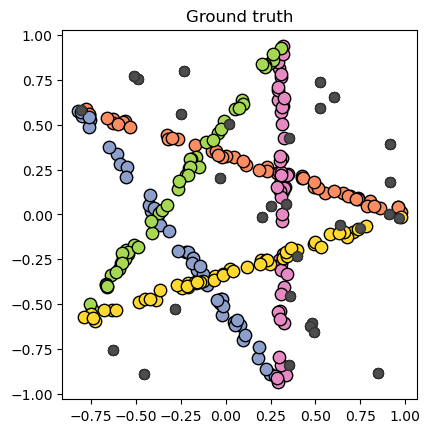

In [9]:
plt.figure(1)
display_clust(X,G, cmap)
plt.title('Ground truth')
plt.gca().set_aspect('equal')
plt.show()

Implement the sequential ransac algorithm

In [10]:
Y = X.copy() # take a copy of X to be modified

# define cells to contain the fitted models
currentModel = []
currentInliers = []
mask = []

E_min = 10 # minimum number of expected inliers for each

cnt = 0
# the last iteration concludes when the number of models found is equal to kappa or the number of points is less than E_min
while cnt < kappa and Y.shape[1] > E_min:
    # find model with ransac (save currentModel and currentInliers for visualization)
    model, inliers, maxscore = lib.simpleRANSAC(Y, epsi, cardmss, verbose=False)
    currentModel.append(model)
    currentInliers.append(inliers)
    mask.append(inliers)
    # remove current inliers
    Y = np.delete(Y, inliers, axis=1)

    # update iterations
    cnt += 1

Show the iteration of Sequential Ransac

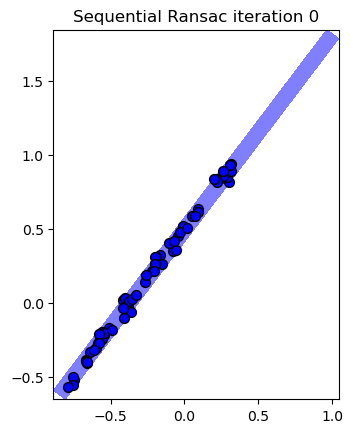

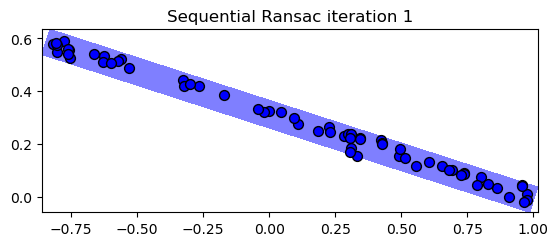

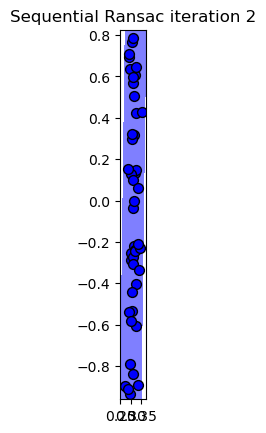

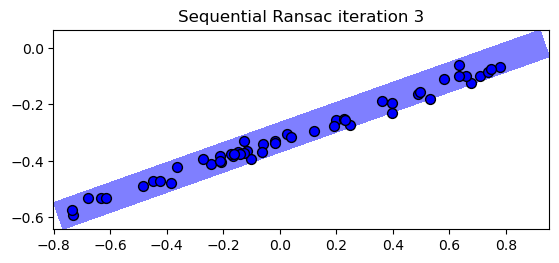

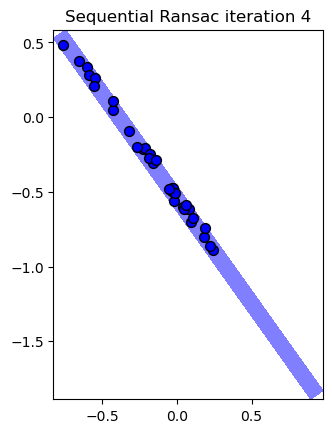

In [11]:
Y = X.copy()
plt.gca().set_aspect('equal')
for i in range(min(kappa, len(currentModel))):
    
    # display a band for each model estimated (see display_band function)
    display_band(Y, currentModel[i], epsi, col)
    
    # plot inliers for this model
    plt.scatter(Y[0, currentInliers[i]], Y[1, currentInliers[i]], 50, col, marker='o', edgecolors='k', alpha=1)
   
    # you need to remove the inliers you have plot from Y, otherwise the indexes are wrong
    Y = np.delete(Y, currentInliers[i], axis=1)

    plt.title(f'Sequential Ransac iteration {i:d}')
    
    plt.show()

/var/folders/w2/bgswx5pn3hjb55_vz5h2hw4m0000gn/T/ipykernel_12418/2832099321.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
/var/folders/w2/bgswx5pn3hjb55_vz5h2hw4m0000gn/T/ipykernel_12418/2832099321.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)


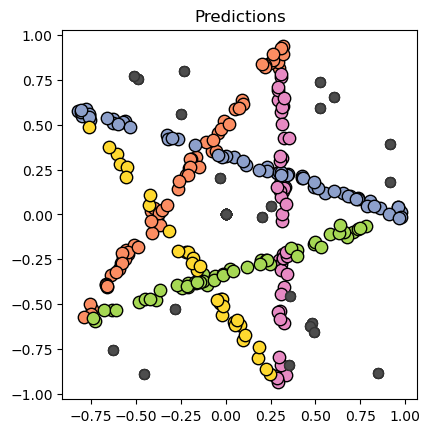

In [12]:
G = np.zeros((X.shape[1], 1))
Y = X.copy()
datapoints = np.zeros_like(Y)
for i, inliers in enumerate(currentInliers):
    datapoints = np.hstack((datapoints, Y[:, inliers]))
    G = np.vstack((G, (i+1)*np.ones((len(inliers), 1))))
    Y = np.delete(Y, inliers, axis=1)

# add the outliers
datapoints = np.hstack((datapoints, Y))
G = np.vstack((G, np.zeros((Y.shape[1], 1))))

plt.figure(1)
display_clust(datapoints,G, cmap)
plt.title('Predictions')
plt.gca().set_aspect('equal')
plt.show()

TODO: Try different amount of outliers on both star and stair datasets

In [13]:
epsi = 5e-3 # inlier threshold for ransac

# temp = loadmat(f'{rootfolder}/data/star5.mat')
temp = loadmat(f'{rootfolder}/data/stair4.mat')

X = temp['X'] # data
G = temp['G'] # ground truth or label (1: normal, 0: outlier)

# model specification
# functions to fit and compute residuals are already invoked in the function
cardmss = 2          # minimum number of points required to fit a model
kappa = 4            # number of models to be extracted by sequential ransac

#  plotting params
bw = 0.01
col = 'b'
temp = loadmat(f'{rootfolder}/data/cmap.mat')
cmap = temp['cmap']

# add outliers
nOut = 10

# add outlier and update groundtruth
X = addOutliersInBB(X, nOut, k=1)

# update the label, considering that X previous command has appended nOut otliers 
G = np.vstack((G, np.zeros((nOut, 1))))

In [14]:
Y = X.copy() # take a copy of X to be modified

# define cells to contain the fitted models
currentModel = []
currentInliers = []
mask = []

E_min = 10 # minimum number of expected inliers for each

cnt = 0
# the last iteration concludes when the number of models found is equal to kappa or the number of points is less than E_min
while cnt < kappa and Y.shape[1] > E_min:
    # find model with ransac (save currentModel and currentInliers for visualization)
    model, inliers, maxscore = lib.simpleRANSAC(Y, epsi, cardmss, verbose=False)
    currentModel.append(model)
    currentInliers.append(inliers)
    mask.append(inliers)
    # remove current inliers
    Y = np.delete(Y, inliers, axis=1)

    # update iterations
    cnt += 1

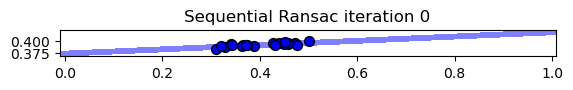

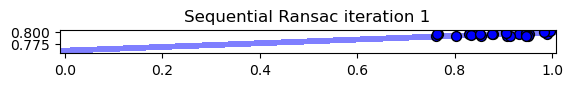

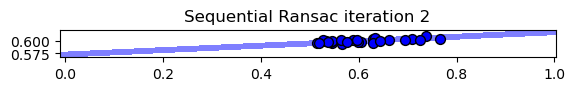

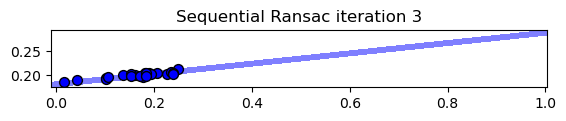

In [15]:
Y = X.copy()
plt.gca().set_aspect('equal')
for i in range(min(kappa, len(currentModel))):
    
    # display a band for each model estimated (see display_band function)
    display_band(Y, currentModel[i], epsi, col)
    
    # plot inliers for this model
    plt.scatter(Y[0, currentInliers[i]], Y[1, currentInliers[i]], 50, col, marker='o', edgecolors='k', alpha=1)
   
    # you need to remove the inliers you have plot from Y, otherwise the indexes are wrong
    Y = np.delete(Y, currentInliers[i], axis=1)

    plt.title(f'Sequential Ransac iteration {i:d}')
    
    plt.show()

/var/folders/w2/bgswx5pn3hjb55_vz5h2hw4m0000gn/T/ipykernel_12418/2832099321.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
/var/folders/w2/bgswx5pn3hjb55_vz5h2hw4m0000gn/T/ipykernel_12418/2832099321.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)


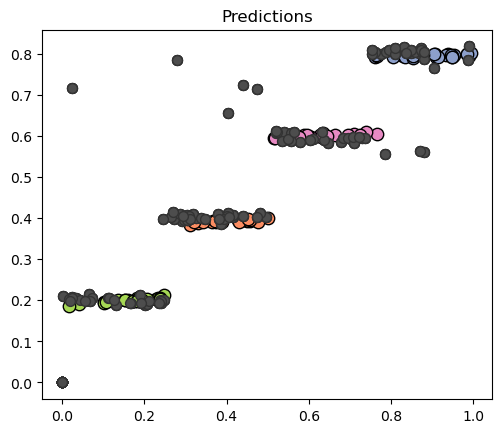

In [16]:
G = np.zeros((X.shape[1], 1))
Y = X.copy()
datapoints = np.zeros_like(Y)
for i, inliers in enumerate(currentInliers):
    datapoints = np.hstack((datapoints, Y[:, inliers]))
    G = np.vstack((G, (i+1)*np.ones((len(inliers), 1))))
    Y = np.delete(Y, inliers, axis=1)

# add the outliers
datapoints = np.hstack((datapoints, Y))
G = np.vstack((G, np.zeros((Y.shape[1], 1))))

plt.figure(1)
display_clust(datapoints,G, cmap)
plt.title('Predictions')
plt.gca().set_aspect('equal')
plt.show()

TODO: MultiModel fitting on circle
----------------------------
Implement Ransac (thus run Sequential Ransac) to fit circles

/var/folders/w2/bgswx5pn3hjb55_vz5h2hw4m0000gn/T/ipykernel_12418/2832099321.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
/var/folders/w2/bgswx5pn3hjb55_vz5h2hw4m0000gn/T/ipykernel_12418/2832099321.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)


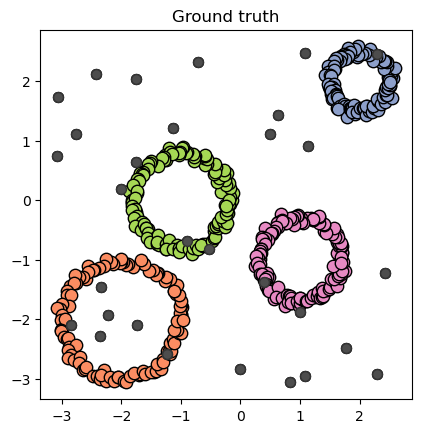

In [17]:
# generate n random points on 4 circles with radius r
r = [1, 0.5, 0.7, 0.8]
centers = [[-2, -2], [2, 2], [1, -1], [-1, 0]]

X = np.zeros((2, 0))
G = np.zeros((0, 1))

for i in range(4):
    n = np.random.randint(100, 150)
    theta = np.linspace(0, 2*np.pi, n)
    x = r[i] * np.cos(theta) + centers[i][0] + 5e-2 * np.random.randn(1, n)
    y = r[i] * np.sin(theta) + centers[i][1] + 5e-2 * np.random.randn(1, n)
    X = np.hstack((X, np.vstack((x, y))))
    G = np.vstack((G, (i+1) * np.ones((n, 1))))

# add outliers
nOut = 30
X = addOutliersInBB(X, nOut, k=1)
G = np.vstack((G, np.zeros((nOut, 1))))

# plot the data
plt.figure(1)
display_clust(X, G, cmap)
plt.title('Ground truth')
plt.gca().set_aspect('equal')
plt.show()

In [18]:
epsi = 1e-1 # inlier threshold for ransac

# model specification
# functions to fit and compute residuals are already invoked in the function
cardmss = 3          # minimum number of points required to fit a model
kappa = 4            # number of models to be extracted by sequential ransac

#  plotting params
bw = 0.01
col = 'b'
temp = loadmat(f'{rootfolder}/data/cmap.mat')
cmap = temp['cmap']

# add outliers
nOut = 10

# add outlier and update groundtruth
X = addOutliersInBB(X, nOut, k=1)

# update the label, considering that X previous command has appended nOut otliers 
G = np.vstack((G, np.zeros((nOut, 1))))

In [19]:
Y = X.copy() # take a copy of X to be modified

# define cells to contain the fitted models
currentModel = []
currentInliers = []

E_min = 10 # minimum number of expected inliers for each

cnt = 0
# the last iteration concludes when the number of models found is equal to kappa or the number of points is less than E_min
while cnt < kappa and Y.shape[1] > E_min:
    # find model with ransac (save currentModel and currentInliers for visualization)
    model, inliers, maxscore = lib.circlesRANSAC(Y, epsi, cardmss, verbose=True)
    currentModel.append(model)
    currentInliers.append(inliers)
    mask.append(inliers)
    # remove current inliers
    Y = np.delete(Y, inliers, axis=1)

    # update iterations
    cnt += 1

Iteration 1/293	 Inliers: 62	 Best inliers: 62
Iteration 2/293	 Inliers: 39	 Best inliers: 62
Iteration 3/293	 Inliers: 26	 Best inliers: 62
Iteration 4/293	 Inliers: 59	 Best inliers: 62
Iteration 5/293	 Inliers: 52	 Best inliers: 62
Iteration 6/293	 Inliers: 61	 Best inliers: 62
Iteration 7/293	 Inliers: 65	 Best inliers: 65
Iteration 8/293	 Inliers: 30	 Best inliers: 65
Iteration 9/293	 Inliers: 66	 Best inliers: 66
Iteration 10/293	 Inliers: 70	 Best inliers: 70
Iteration 11/293	 Inliers: 60	 Best inliers: 70
Iteration 12/293	 Inliers: 71	 Best inliers: 71
Iteration 13/293	 Inliers: 44	 Best inliers: 71
Iteration 14/293	 Inliers: 35	 Best inliers: 71
Iteration 15/293	 Inliers: 51	 Best inliers: 71
Iteration 16/293	 Inliers: 43	 Best inliers: 71
Iteration 17/293	 Inliers: 67	 Best inliers: 71
Iteration 18/293	 Inliers: 19	 Best inliers: 71
Iteration 19/293	 Inliers: 35	 Best inliers: 71
Iteration 20/293	 Inliers: 64	 Best inliers: 71
Iteration 21/293	 Inliers: 33	 Best inliers: 71
I

/var/folders/w2/bgswx5pn3hjb55_vz5h2hw4m0000gn/T/ipykernel_12418/2832099321.py:56: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x,y,80,cmap[i,:],marker=smb,edgecolors='k', alpha=1)
/var/folders/w2/bgswx5pn3hjb55_vz5h2hw4m0000gn/T/ipykernel_12418/2832099321.py:62: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X[0, id],X[1, id],50,[0.3,0.3,0.3],marker=smb,edgecolors=[0.2,0.2,0.2], alpha=1)


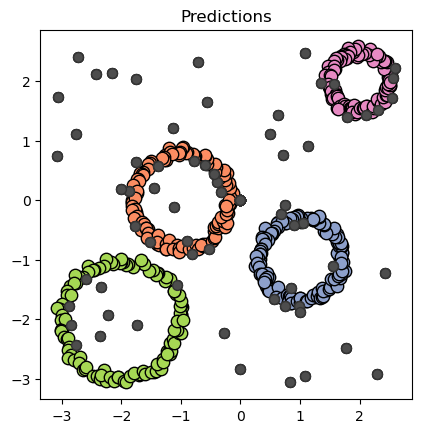

In [20]:
G = np.zeros((X.shape[1], 1))
Y = X.copy()
datapoints = np.zeros_like(Y)
for i, inliers in enumerate(currentInliers):
    datapoints = np.hstack((datapoints, Y[:, inliers]))
    G = np.vstack((G, (i+1) * np.ones((len(inliers), 1))))
    Y = np.delete(Y, inliers, axis=1)

# add the outliers
datapoints = np.hstack((datapoints, Y))
G = np.vstack((G, np.zeros((Y.shape[1], 1))))

plt.figure(1)
display_clust(datapoints,G, cmap)
plt.title('Predictions')
plt.gca().set_aspect('equal')
plt.show()